# Capability 01 — PostgreSQL to Neo4j projection
Live reconciliation and graph-shape evidence for the POC-managed projection.

In [1]:
import json
import sys
from dataclasses import asdict
from pathlib import Path

repo = Path.cwd()
if not (repo / "src").exists():
    repo = repo.parents[1]
sys.path.insert(0, str(repo / "src"))
from dotenv import load_dotenv

load_dotenv(repo / ".env")
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from sqlalchemy import func, select

from telco_digital.config import get_settings
from telco_digital.infrastructure.postgres.graph_snapshot import load_graph_snapshot
from telco_digital.infrastructure.postgres.models import OutboxEventModel
from telco_digital.infrastructure.postgres.session import create_engine

out = repo / "notebooks" / "01_graph_projection" / "outputs"
tables = out / "tables"
plots = out / "plots"
tables.mkdir(parents=True, exist_ok=True)
plots.mkdir(parents=True, exist_ok=True)

In [2]:
settings = get_settings()
engine = create_engine(settings)
snapshot = await load_graph_snapshot(engine)
source_counts = {name: len(rows) for name, rows in asdict(snapshot).items()}
async with engine.connect() as connection:
    status_rows = (
        await connection.execute(
            select(OutboxEventModel.status, func.count()).group_by(OutboxEventModel.status)
        )
    ).all()
await engine.dispose()
outbox_status = {status: count for status, count in status_rows}
source_counts, outbox_status

({'customers': 1010,
  'accounts': 1010,
  'devices': 967,
  'customer_devices': 1010,
  'plans': 12,
  'subscriptions': 1009,
  'wallets': 1005,
  'merchants': 20,
  'transactions': 2010,
  'distributors': 5,
  'retailers': 25,
  'sales_agents': 10,
  'products': 12,
  'sales': 1200,
  'inventory_events': 1200},
 {'PROCESSED': 19811})

In [3]:
with GraphDatabase.driver(
    settings.neo4j_uri, auth=(settings.neo4j_user, settings.neo4j_password)
) as driver:
    driver.verify_connectivity()
    node_rows = driver.execute_query(
        "MATCH (n {projection: 'poc-v1'}) RETURN labels(n)[0] AS kind, count(*) AS total ORDER BY kind",
        result_transformer_=lambda r: r.data(),
    )
    rel_rows = driver.execute_query(
        "MATCH ()-[r {projection: 'poc-v1'}]->() RETURN type(r) AS kind, count(*) AS total ORDER BY kind",
        result_transformer_=lambda r: r.data(),
    )
    degrees = driver.execute_query(
        "MATCH (c:Customer {projection: 'poc-v1'}) OPTIONAL MATCH (c)-[r]-() RETURN c.customer_ref AS customer_ref, count(r) AS degree ORDER BY degree DESC, customer_ref LIMIT 25",
        result_transformer_=lambda r: r.data(),
    )
    shared_devices = driver.execute_query(
        "MATCH (d:Device {projection: 'poc-v1'})<-[:USES]-(c:Customer) WITH d, count(c) AS customers WHERE customers > 1 RETURN d.device_ref AS device_ref, customers ORDER BY customers DESC, device_ref",
        result_transformer_=lambda r: r.data(),
    )
node_counts = {row["kind"]: row["total"] for row in node_rows}
relationship_counts = {row["kind"]: row["total"] for row in rel_rows}
node_counts, relationship_counts, shared_devices[:5]

({'Account': 1010,
  'Customer': 1010,
  'Device': 967,
  'Distributor': 5,
  'Merchant': 20,
  'Plan': 12,
  'Product': 12,
  'Retailer': 25,
  'SalesAgent': 10,
  'Transaction': 2010,
  'Wallet': 1005},
 {'AT_MERCHANT': 1988,
  'FROM_WALLET': 2010,
  'INITIATED': 2010,
  'INVENTORY_EVENT': 1200,
  'OWNS_WALLET': 1005,
  'SOLD': 1200,
  'SUBSCRIBES_TO': 1009,
  'SUPPLIED_BY': 25,
  'TO_WALLET': 22,
  'USED_DEVICE': 2010,
  'USES': 1010,
  'WORKS_FOR': 10},
 [{'device_ref': 'D001', 'customers': 3},
  {'device_ref': 'DEV-SHARED_001', 'customers': 3},
  {'device_ref': 'DEV-SHARED_002', 'customers': 3},
  {'device_ref': 'DEV-SHARED_003', 'customers': 3},
  {'device_ref': 'DEV-SHARED_004', 'customers': 3}])

In [4]:
mapping = {
    "customers": "Customer",
    "accounts": "Account",
    "devices": "Device",
    "plans": "Plan",
    "wallets": "Wallet",
    "merchants": "Merchant",
    "transactions": "Transaction",
    "distributors": "Distributor",
    "retailers": "Retailer",
    "sales_agents": "SalesAgent",
    "products": "Product",
}
reconciliation = [
    {
        "source": source,
        "graph": label,
        "postgres": source_counts[source],
        "neo4j": node_counts.get(label, 0),
        "difference": node_counts.get(label, 0) - source_counts[source],
    }
    for source, label in mapping.items()
]
metrics = {
    "projection": "poc-v1",
    "source_counts": source_counts,
    "node_counts": node_counts,
    "relationship_counts": relationship_counts,
    "outbox_status": outbox_status,
    "reconciled": all(row["difference"] == 0 for row in reconciliation),
    "shared_device_count": len(shared_devices),
    "max_customer_degree": max((row["degree"] for row in degrees), default=0),
}
(out / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(tables / "reconciliation.json").write_text(json.dumps(reconciliation, indent=2), encoding="utf-8")
(tables / "customer_degrees.json").write_text(json.dumps(degrees, indent=2), encoding="utf-8")
(tables / "shared_devices.json").write_text(json.dumps(shared_devices, indent=2), encoding="utf-8")
metrics

{'projection': 'poc-v1',
 'source_counts': {'customers': 1010,
  'accounts': 1010,
  'devices': 967,
  'customer_devices': 1010,
  'plans': 12,
  'subscriptions': 1009,
  'wallets': 1005,
  'merchants': 20,
  'transactions': 2010,
  'distributors': 5,
  'retailers': 25,
  'sales_agents': 10,
  'products': 12,
  'sales': 1200,
  'inventory_events': 1200},
 'node_counts': {'Account': 1010,
  'Customer': 1010,
  'Device': 967,
  'Distributor': 5,
  'Merchant': 20,
  'Plan': 12,
  'Product': 12,
  'Retailer': 25,
  'SalesAgent': 10,
  'Transaction': 2010,
  'Wallet': 1005},
 'relationship_counts': {'AT_MERCHANT': 1988,
  'FROM_WALLET': 2010,
  'INITIATED': 2010,
  'INVENTORY_EVENT': 1200,
  'OWNS_WALLET': 1005,
  'SOLD': 1200,
  'SUBSCRIBES_TO': 1009,
  'SUPPLIED_BY': 25,
  'TO_WALLET': 22,
  'USED_DEVICE': 2010,
  'USES': 1010,
  'WORKS_FOR': 10},
 'outbox_status': {'PROCESSED': 19811},
 'reconciled': True,
 'shared_device_count': 22,
 'max_customer_degree': 6}

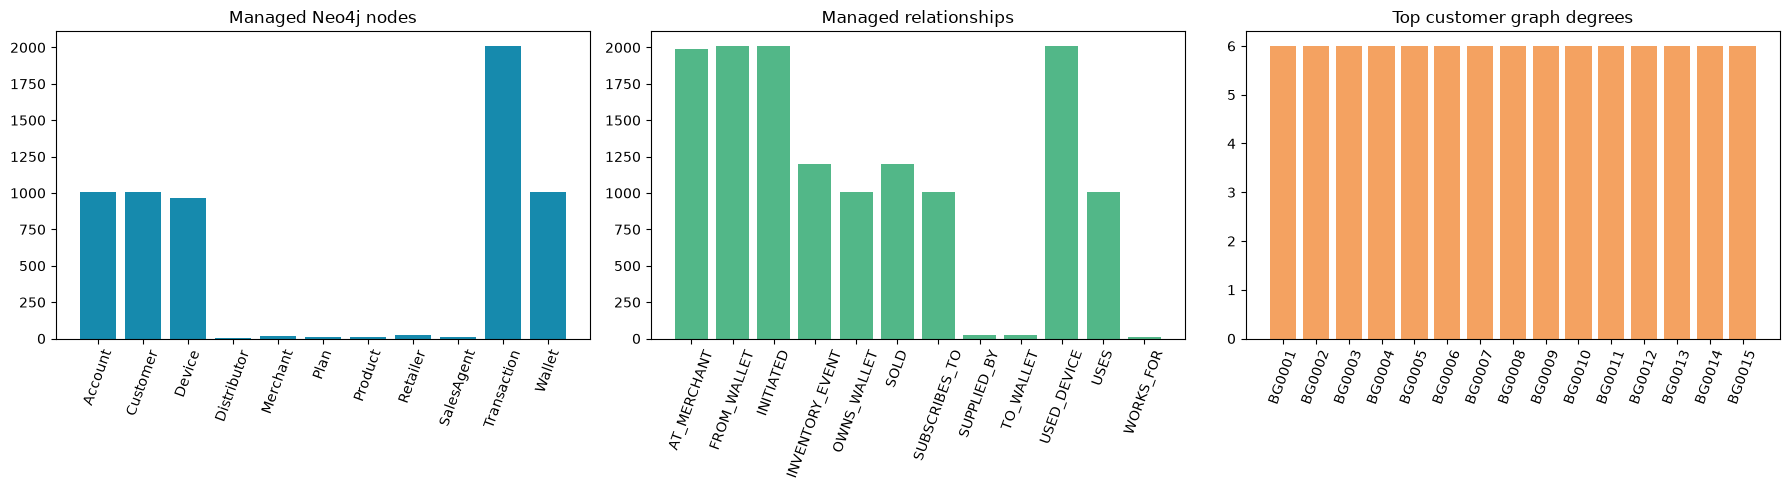

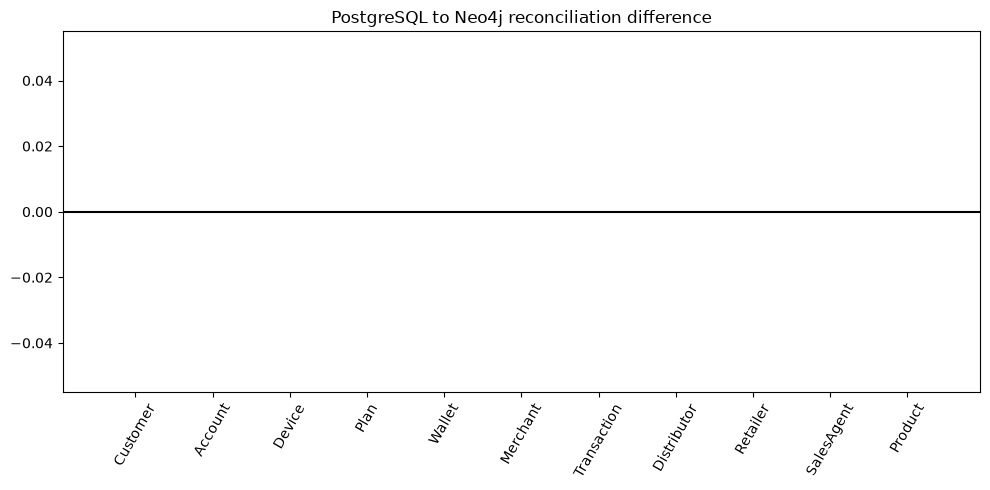

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(node_counts.keys(), node_counts.values(), color="#168aad")
axes[0].set_title("Managed Neo4j nodes")
axes[0].tick_params(axis="x", rotation=70)
axes[1].bar(relationship_counts.keys(), relationship_counts.values(), color="#52b788")
axes[1].set_title("Managed relationships")
axes[1].tick_params(axis="x", rotation=70)
axes[2].bar(
    [row["customer_ref"] for row in degrees[:15]],
    [row["degree"] for row in degrees[:15]],
    color="#f4a261",
)
axes[2].set_title("Top customer graph degrees")
axes[2].tick_params(axis="x", rotation=70)
fig.tight_layout()
fig.savefig(plots / "projection_graph_summary.png", dpi=150, bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    [row["graph"] for row in reconciliation],
    [row["difference"] for row in reconciliation],
    color="#2a9d8f",
)
ax.axhline(0, color="black")
ax.set_title("PostgreSQL to Neo4j reconciliation difference")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
fig.savefig(plots / "source_projection_reconciliation.png", dpi=150, bbox_inches="tight")
plt.show()